In [ ]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.3 MB/s eta 0:00:00


In [ ]:
!pip install qiskit[visualization]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=7be13c63ed8a17255e44c01fb305296ca50500ed658302c3b0ddd5f1e6a95f37
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 79.2 MB/s eta 0:00:00


In [ ]:
# Import required libraries
from qiskit import *
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt


In [ ]:
# Create 3 qubits: 0 - sender qubit (to teleport)
#                 1 - Alice's entangled qubit
#                 2 - Bob's entangled qubit
qc = QuantumCircuit(3, 2)

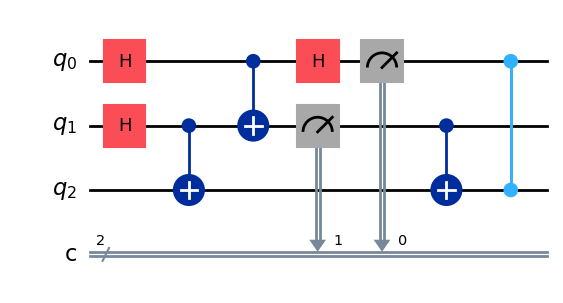

In [ ]:
# Step A: Prepare the state to be teleported (|+⟩ state)
qc.h(0)

# Step B: Create entangled Bell pair between qubits 1 & 2
qc.h(1)
qc.cx(1, 2)

# Step C: Apply teleportation protocol
qc.cx(0, 1)
qc.h(0)

# Step D: Measure Alice’s qubits (0 & 1)
qc.measure(0, 0)
qc.measure(1, 1)

# Step E: Conditional operations on Bob’s qubit
qc.cx(1, 2)
qc.cz(0, 2)

qc.draw('mpl')

{'11': 227, '00': 264, '10': 273, '01': 260}


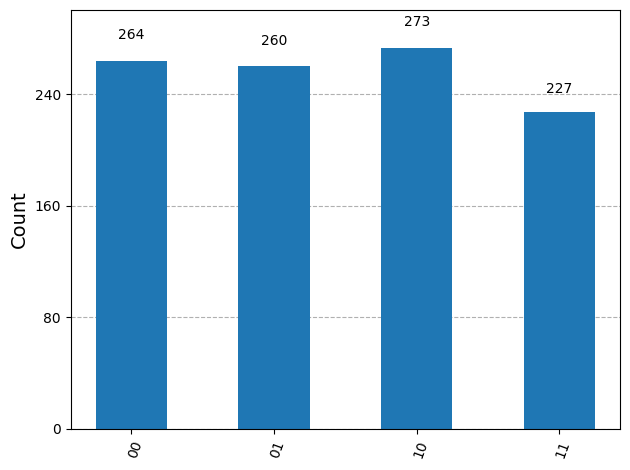

In [ ]:
from qiskit_aer import Aer
simulator = Aer.get_backend('aer_simulator')
compiled = transpile(qc, simulator)
job = simulator.run(compiled, shots=1024)
result = job.result()
counts = result.get_counts()
print(counts)
plot_histogram(counts)